Name:  Siddhi Shashikant Gandhi

Roll No. 33

Batch  : T2

In [ ]:
!pip install transformers torch pillow

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

print("Model Loaded ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model Loaded ✅


In [ ]:
img = Image.open("/content/dog playing.jpg")  # upload any image

inputs = processor(img, return_tensors="pt")
output = model.generate(**inputs)

caption = processor.decode(output[0], skip_special_tokens=True)
print("Caption:", caption)

Caption: a dog running with a ball in its mouth


In [ ]:
model.save_pretrained("/content/caption_model")
processor.save_pretrained("/content/caption_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/caption_model/processor_config.json']

In [ ]:
import shutil
shutil.make_archive("caption_model", 'zip', "/content/caption_model")

from google.colab import files
files.download("caption_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Index.Html

In [ ]:
<!DOCTYPE html>
<html>
<head>
    <title>Image Caption Generator</title>
    <style>
        body {
            font-family: Arial;
            text-align: center;
            background: #f2f2f2;
            padding: 40px;
        }

        .container {
            background: white;
            padding: 20px;
            border-radius: 10px;
            width: 50%;
            margin: auto;
        }

        img {
            max-width: 100%;
            margin-top: 20px;
        }

        button {
            padding: 10px 20px;
            margin-top: 10px;
        }
    </style>
</head>
<body>

<div class="container">
    <h1>📸 Image Caption Generator</h1>

    <form method="POST" enctype="multipart/form-data">
        <input type="file" name="image" required><br>
        <button type="submit">Generate Caption</button>
    </form>

    {% if image_path %}
        <img src="{{ image_path }}">
    {% endif %}

    {% if caption %}
        <h3>Caption:</h3>
        <p>{{ caption }}</p>
    {% endif %}
</div>

</body>
</html>

# app.py

In [ ]:
from flask import Flask, render_template, request
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import os

app = Flask(__name__)

# Load model
processor = BlipProcessor.from_pretrained("caption_model")
model = BlipForConditionalGeneration.from_pretrained("caption_model")

UPLOAD_FOLDER = "static/uploads"
app.config["UPLOAD_FOLDER"] = UPLOAD_FOLDER

def generate_caption(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = processor(img, return_tensors="pt")
    output = model.generate(**inputs)
    caption = processor.decode(output[0], skip_special_tokens=True)
    return caption

@app.route("/", methods=["GET", "POST"])
def index():
    caption = ""
    image_path = ""

    if request.method == "POST":
        file = request.files["image"]
        if file:
            path = os.path.join(app.config["UPLOAD_FOLDER"], file.filename)
            file.save(path)

            image_path = path
            caption = generate_caption(path)

    return render_template("index.html", caption=caption, image_path=image_path)

if __name__ == "__main__":
    app.run(debug=True)

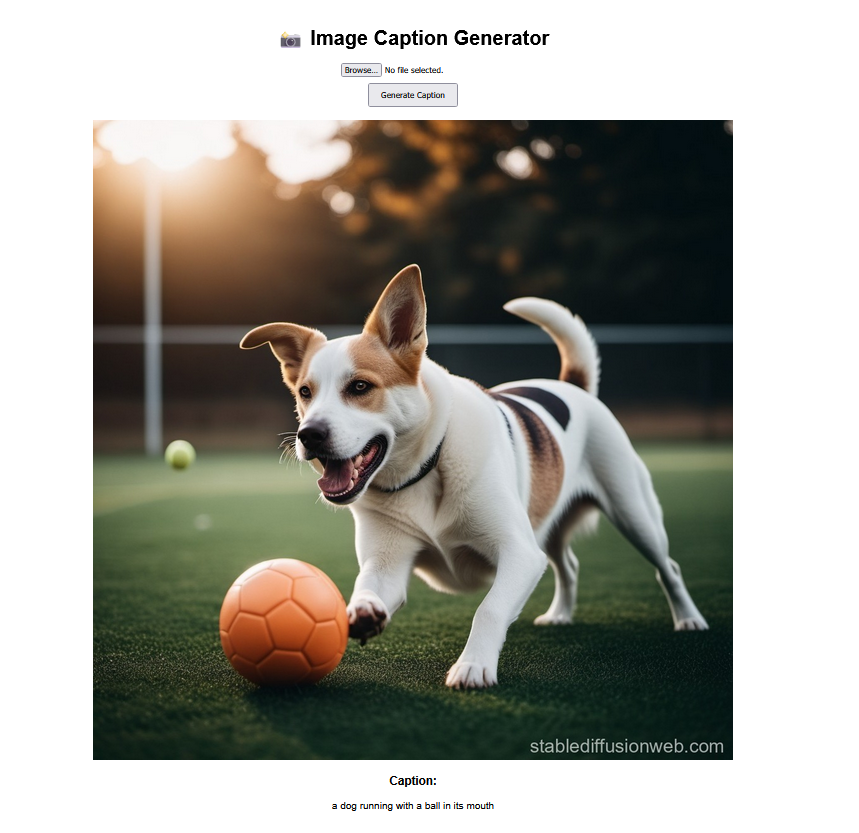